scPred-Py initialized. Remember this is a starting point!
--- Setting up environment for reproducibility ---

--- Step 1: Loading and Annotating paul15 Data ---
Data loading and labeling complete.

--- Step 2: Splitting Data ---
Data splitting complete.


--- Step 4: Running Comparative Analyses on paul15 ---

  RUNNING EXPERIMENT: Linear SVM (2000 HVGs)
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 2000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 30 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='linear', C=1.0, class_weight='None'...
Training finished.
--- ScP

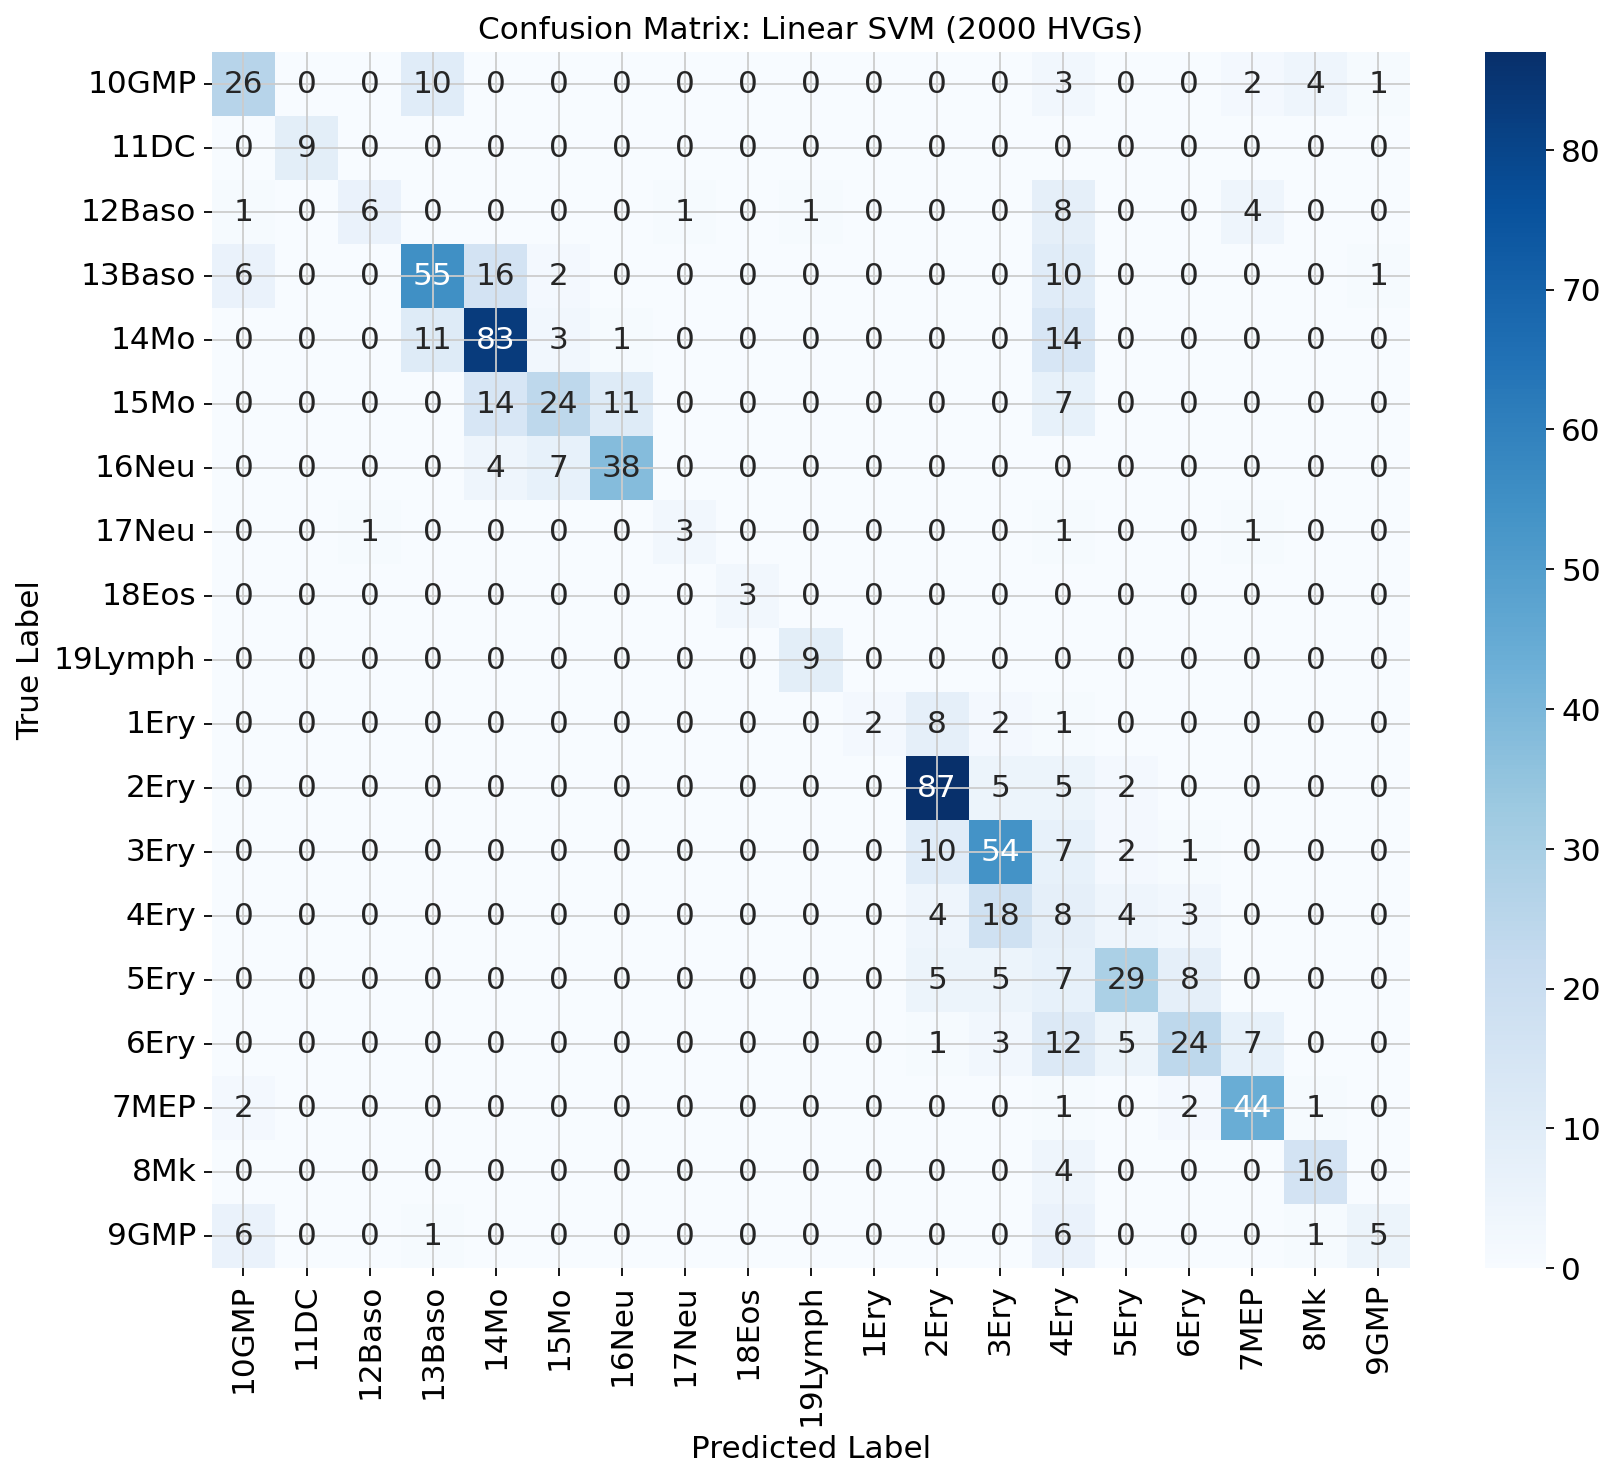


  RUNNING EXPERIMENT: RBF SVM (2000 HVGs)
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 2000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 30 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='rbf', C=1.0, class_weight='None'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Aligning 3438 genes to 2000 reference genes

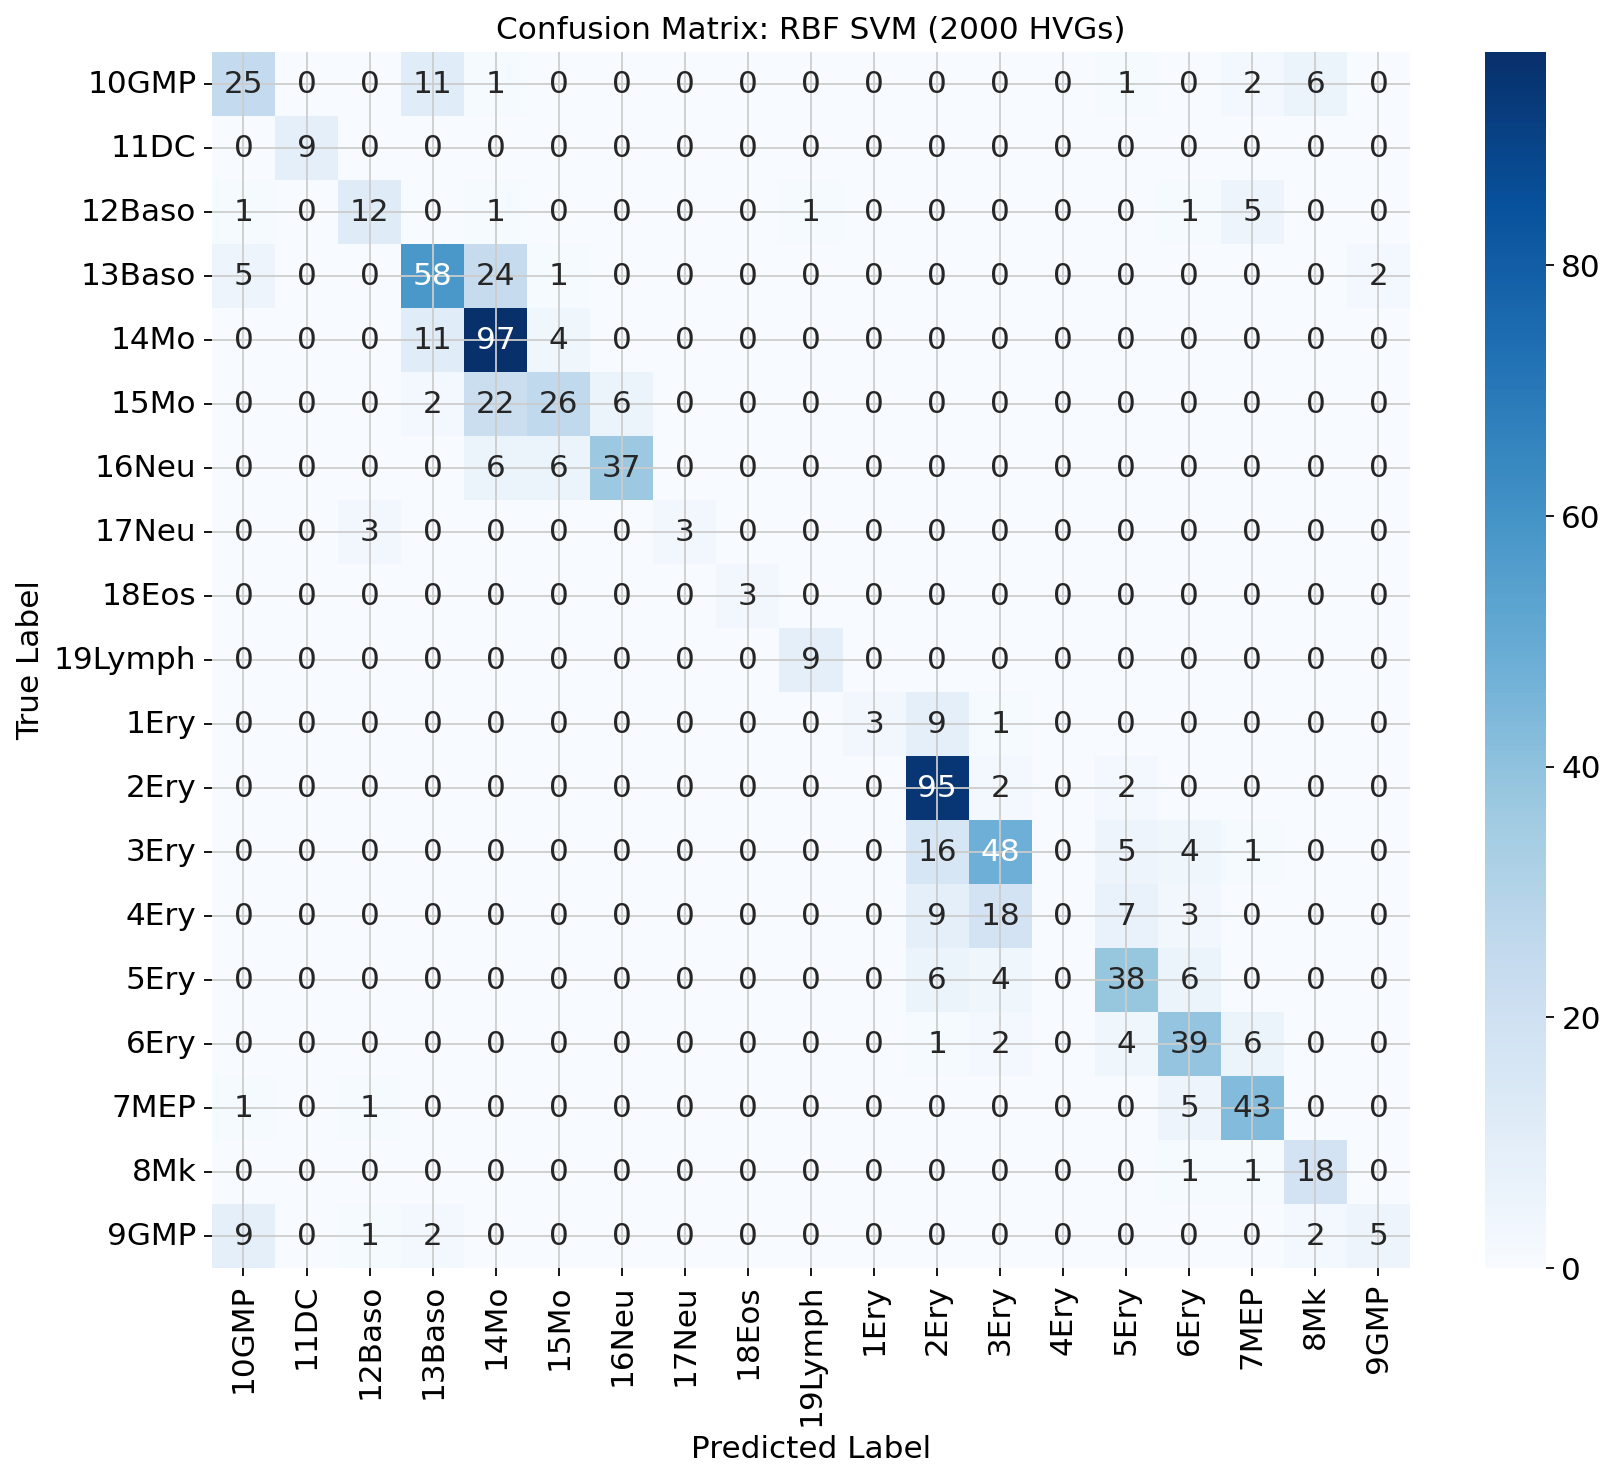


  RUNNING EXPERIMENT: RBF SVM (Balanced, 2000 HVGs)
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 2000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 30 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='rbf', C=1.0, class_weight='balanced'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Aligning 3438 genes to 2000 r

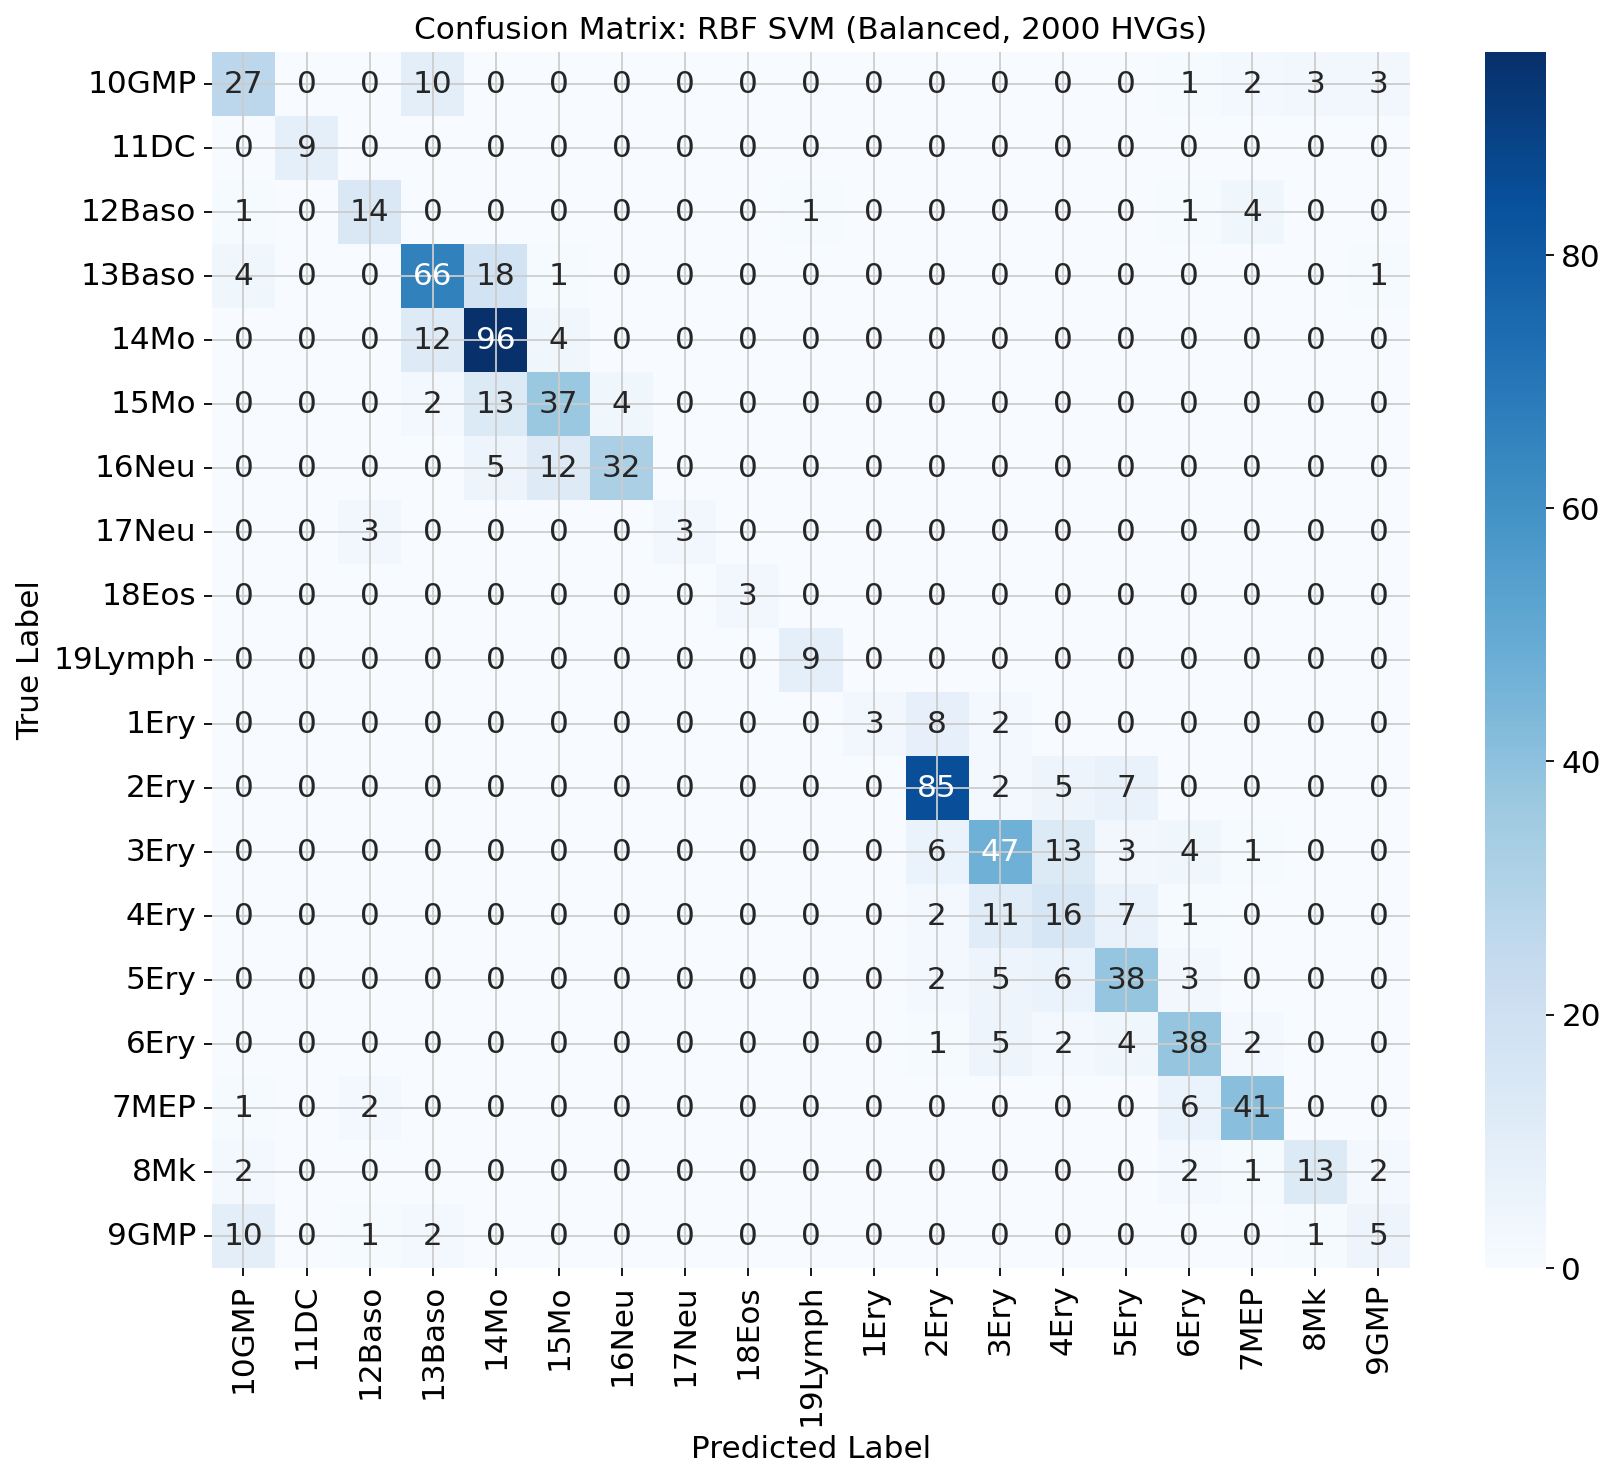


  RUNNING EXPERIMENT: RBF SVM (Balanced, C=10, 2000 HVGs)
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 2000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 30 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='rbf', C=10.0, class_weight='balanced'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Aligning 3438 genes to

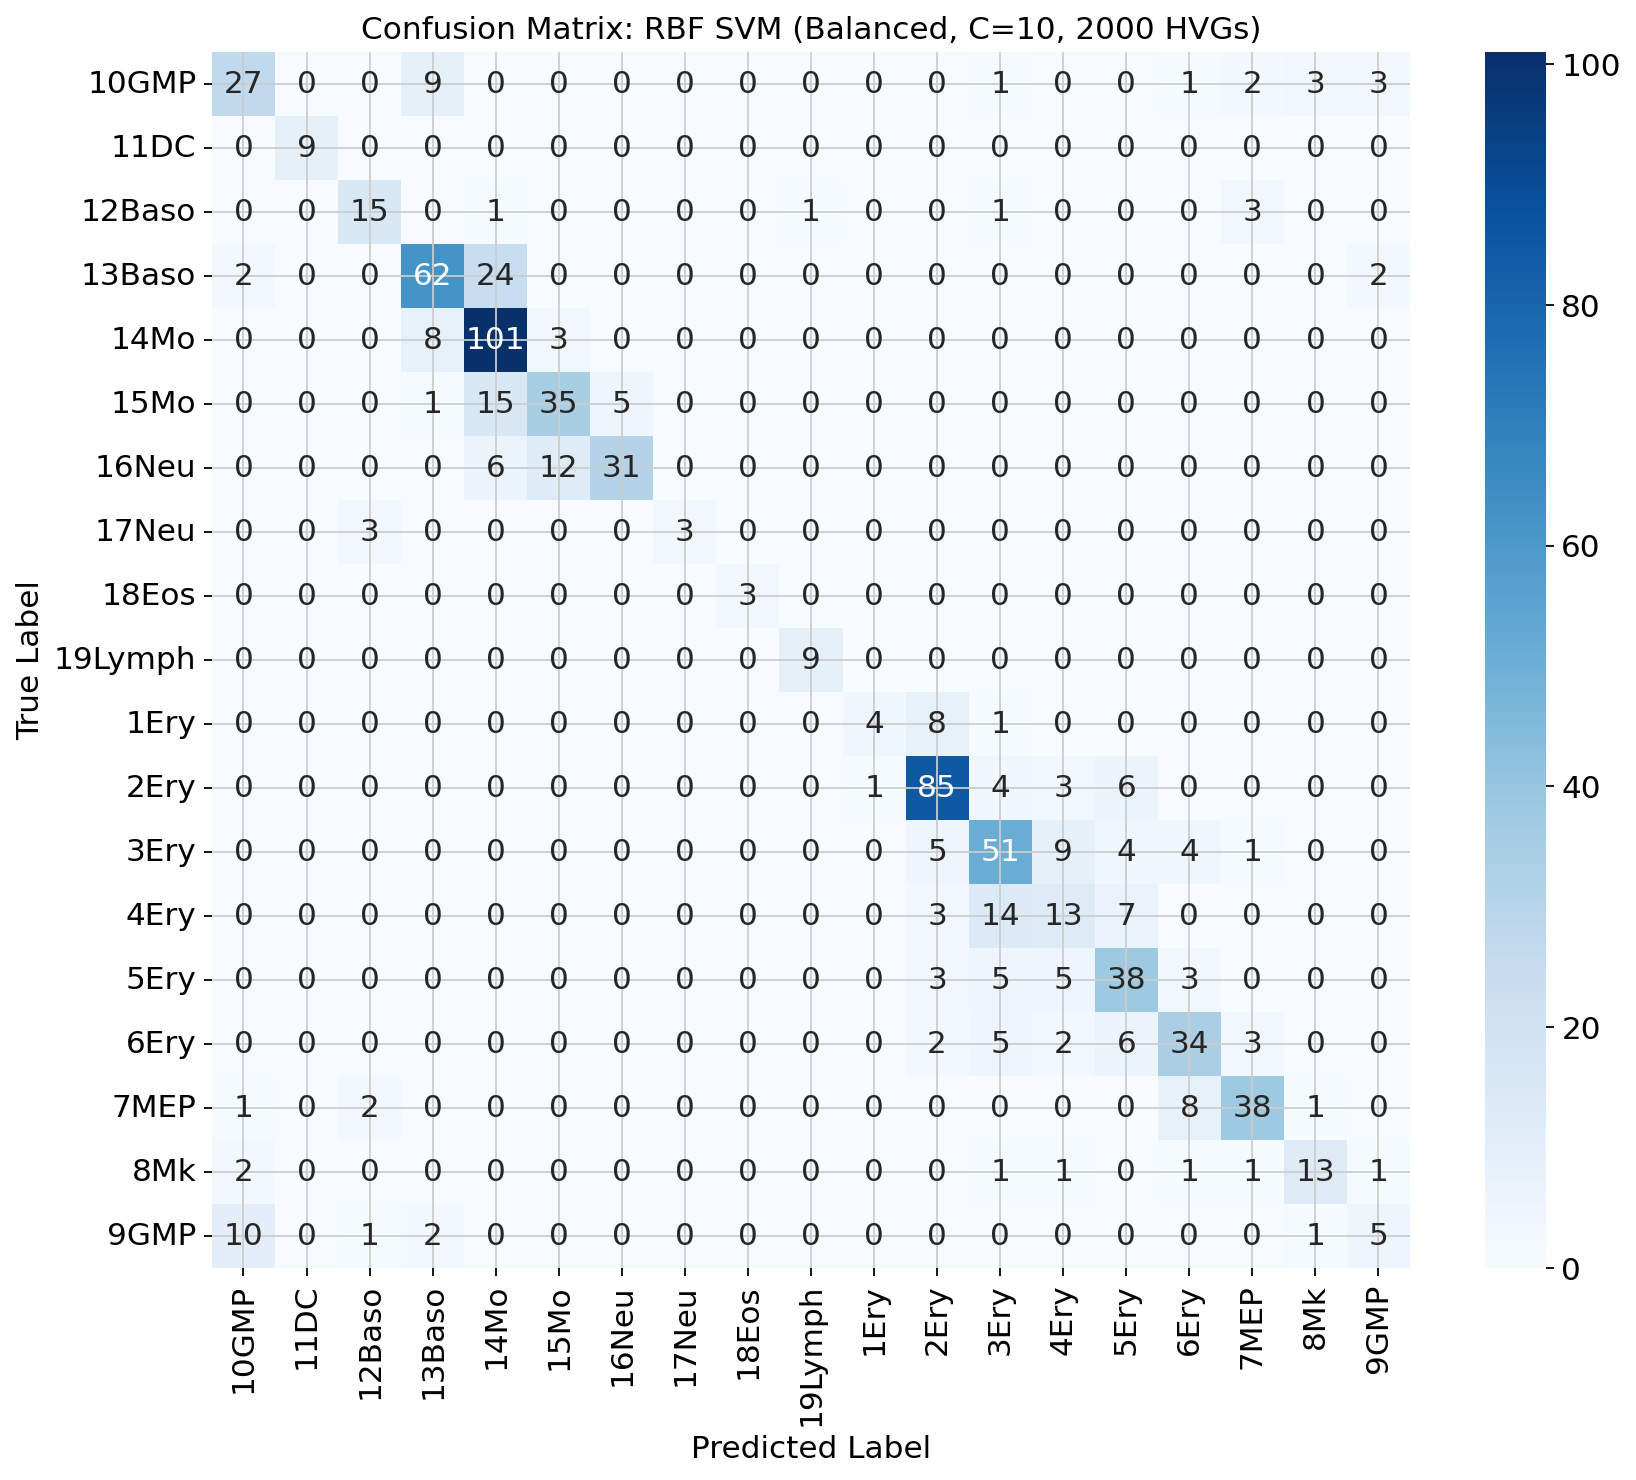



  FINAL RESULTS SUMMARY (paul15)
| Experiment                          |   Accuracy |   Balanced Accuracy |      MCC |
|:------------------------------------|-----------:|--------------------:|---------:|
| Linear SVM (2000 HVGs)              |   0.641026 |            0.6225   | 0.611044 |
| RBF SVM (2000 HVGs)                 |   0.693529 |            0.666352 | 0.666368 |
| RBF SVM (Balanced, 2000 HVGs)       |   0.710623 |            0.683286 | 0.684257 |
| RBF SVM (Balanced, C=10, 2000 HVGs) |   0.703297 |            0.678268 | 0.676347 |

--- Analysis Complete ---


In [1]:
# --- 0. Imports and Setup ---
import scanpy as sc
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

# Adjust the path to import your package
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from scpred_py_final import ScPredModel
from scpred_py_final import _analysis_utils

# --- Environment Setup ---
print("--- Setting up environment for reproducibility ---")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
sc.settings.set_figure_params(dpi=80, facecolor='white')

# --- 1. Data Loading and Annotation ---
print("\n--- Step 1: Loading and Annotating paul15 Data ---")
adata = sc.datasets.paul15()
adata.var_names_make_unique()
# Use the existing cluster annotations
adata.obs['cell_type'] = adata.obs['paul15_clusters'].astype('category')
print("Data loading and labeling complete.")

# --- 2. Train-Test Split ---
print("\n--- Step 2: Splitting Data ---")
indices = range(adata.n_obs)
ref_idx, query_idx = train_test_split(
    indices, test_size=0.3, random_state=RANDOM_STATE, stratify=adata.obs['cell_type']
)
ref_adata_raw = adata[ref_idx, :].copy()
query_adata_raw = adata[query_idx, :].copy()
print("Data splitting complete.")

# --- 3. Define the Experiment Runner Function ---
# (This function is identical to the one in the pbmc3k notebook, so it is omitted here for brevity)
# (Just copy the full `run_scpred_experiment` function here)
def run_scpred_experiment(experiment_name, ref_data, query_data, hvg_genes, svm_params):
    """
    A helper function to run a single scPred experiment with given parameters.
    """
    print("\n" + "="*50)
    print(f"  RUNNING EXPERIMENT: {experiment_name}")
    print("="*50)
    
    model = ScPredModel()
    model.train(
        ref_adata=ref_data,
        cell_type_key='cell_type',
        n_components=30,
        hvg_n_top_genes=hvg_genes, # Pass as parameter
        **svm_params
    )
    
    query_pred = model.predict(query_data)
    
    true_labels = query_pred.obs['cell_type']
    predicted_labels = query_pred.obs['scpred_prediction']
    
    print(f"\n--- Results for: {experiment_name} ---")
    accuracy = accuracy_score(true_labels, predicted_labels)
    print(f"Overall Accuracy: {accuracy:.4f}")
    
    metrics = _analysis_utils.evaluate_and_report_metrics(
        true_labels=true_labels,
        predicted_labels=predicted_labels,
        classifier_classes=model.classifier_.classes_
    )
    
    cm_labels_str = sorted(list(set(true_labels.astype(str).unique()) | set(predicted_labels.astype(str).unique())))
    cm = confusion_matrix(true_labels.astype(str), predicted_labels.astype(str), labels=cm_labels_str)
    cm_df = pd.DataFrame(cm, index=cm_labels_str, columns=cm_labels_str)
    
    plt.figure(figsize=(12, 10)) # Larger figure for more classes
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {experiment_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
    
    return {
        "Experiment": experiment_name,
        "Accuracy": accuracy,
        "Balanced Accuracy": metrics.get('balanced_accuracy'),
        "MCC": metrics.get('mcc')
    }


# --- 4. Run Comparative Experiments ---
print("\n\n--- Step 4: Running Comparative Analyses on paul15 ---")

# For Paul15, let's try more HVGs and a higher C value for the RBF kernel
# to see if it can handle the increased complexity.
experiments_to_run_paul15 = {
    "Linear SVM (2000 HVGs)": {
        'svm_kernel': 'linear', 'svm_c': 1.0, 'svm_random_state': RANDOM_STATE, 'class_weight': None
    },
    "RBF SVM (2000 HVGs)": {
        'svm_kernel': 'rbf', 'svm_c': 1.0, 'svm_random_state': RANDOM_STATE, 'class_weight': None
    },
    "RBF SVM (Balanced, 2000 HVGs)": {
        'svm_kernel': 'rbf', 'svm_c': 1.0, 'svm_random_state': RANDOM_STATE, 'class_weight': 'balanced'
    },
    "RBF SVM (Balanced, C=10, 2000 HVGs)": {
        'svm_kernel': 'rbf', 'svm_c': 10.0, 'svm_random_state': RANDOM_STATE, 'class_weight': 'balanced'
    }
}


results_list_paul15 = []
for name, params in experiments_to_run_paul15.items():
    # Pass 2000 HVGs for all paul15 experiments
    result = run_scpred_experiment(name, ref_adata_raw.copy(), query_adata_raw.copy(), 2000, params)
    results_list_paul15.append(result)


# --- 5. Summarize Results ---
print("\n\n" + "="*50)
print("  FINAL RESULTS SUMMARY (paul15)")
print("="*50)

results_df_paul15 = pd.DataFrame(results_list_paul15)
print(results_df_paul15.to_markdown(index=False))

print("\n--- Analysis Complete ---")